# PoD_esti v10 —— per-shot `hist_i` / `hist_add` 重算

> **基于 `PoD_esti_v05`，不基于 v06。** 本次**不复用** v05/v06 缓存，全量重算。

## 架构约定

每次 Monte Carlo（蒙特卡洛）实现仿真最多 **N_SHOTS_MAX = 4** 发，得到：

- `hist_i`：第 i 发、宏像元 27 SPAD（Single-Photon Avalanche Diode，单光子雪崩二极管）的二值累加直方图
- `hist_add(N) = hist_1 + … + hist_N`，N ∈ {1, 2, 4} —— **取前缀和**，避免对 N=1/2 再仿真

| 符号 | 定义 |
|---|---|
| **noise** | 单次 `hist_i` 统计窗均值（环境标准；与 N 无关） |
| **bg** | `hist_add` 统计窗均值 |
| **peak** | 在 `hist_add` 上统计（纯噪声用统计窗；含信号用信号窗） |

## 本版三张关键图

1. **纯噪声 peak–bg 曲线**（N=1/2/4）—— 关心形状是否一致  
2. **bg + 5·std(peak)** 与 **1% FAR 阈值** 对比  
3. **固定信号、noise 线性增长**：peak 分布是否只是平移；均值/std 是否随 noise 线性

## 数据

```powershell
$env:PYTHONIOENCODING="utf-8"
python run_pod_v10_scan.py all --workers 20
```

产物：`pod_esti_v10_cache_noise.npz`、`pod_esti_v10_cache_signal.npz`

In [1]:
import os
os.environ["POD_CORE_QUIET"] = "1"
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 中文字体
for _f in ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]:
    try:
        rcParams["font.sans-serif"] = [_f]
        break
    except Exception:
        pass
rcParams["axes.unicode_minus"] = False

import pod_esti_v10_core as core

CACHE_NOISE = core.CACHE_NOISE
CACHE_SIG = core.CACHE_SIG
N_LIST = list(core.N_SHOTS_LIST)
COLORS = {1: "tab:blue", 2: "tab:green", 4: "tab:red"}
FAR_1PCT = 0.01


def peak_stats(cnt):
    return core.peak_stats_from_cnt(np.asarray(cnt, dtype=np.int64))


def far_T(cnt, far=FAR_1PCT):
    T, f_meas, nev, sf = core.far_threshold_from_cnt(np.asarray(cnt, dtype=np.int64), far)
    return T, f_meas, nev


def load_noise(path=CACHE_NOISE):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"缺少 {path}。请先：python run_pod_v10_scan.py noise --workers 20")
    z = np.load(path, allow_pickle=True)
    out = {"noise_target": np.asarray(z["noise_target"], float),
           "r_det": np.asarray(z["r_det"], float),
           "e_lambda": np.asarray(z["e_lambda"], float),
           "p_eq": np.asarray(z["p_eq"], float),
           "n_mc": int(z["n_mc"]),
           "by_N": {}}
    for n in N_LIST:
        cnt = np.asarray(z[f"peak_cnt_{n}"])
        stats = [peak_stats(c) for c in cnt]
        T1 = np.array([far_T(c, FAR_1PCT)[0] for c in cnt])
        out["by_N"][n] = {
            "noise_mc": np.asarray(z[f"noise_mc_{n}"], float),
            "bg_mc": np.asarray(z[f"bg_mc_{n}"], float),
            "bg_std": np.asarray(z[f"bg_std_{n}"], float),
            "peak_cnt": cnt,
            "peak_mean": np.array([s["mean"] for s in stats]),
            "peak_std": np.array([s["std"] for s in stats]),
            "peak_p50": np.array([s["p50"] for s in stats]),
            "peak_p99": np.array([s["p99"] for s in stats]),
            "T_1pct": T1,
        }
    print(f"噪声缓存 {path}: {out['noise_target'].size} 档, N_MC={out['n_mc']:,}")
    for n in N_LIST:
        d = out["by_N"][n]
        print(f"  N={n}: bg {d['bg_mc'][0]:.3f}→{d['bg_mc'][-1]:.3f}, "
              f"noise {d['noise_mc'][0]:.3f}→{d['noise_mc'][-1]:.3f}, "
              f"中位 bg/noise={np.nanmedian(d['bg_mc']/np.maximum(d['noise_mc'],1e-12)):.2f}")
    return out


def load_signal(path=CACHE_SIG):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"缺少 {path}。请先：python run_pod_v10_scan.py signal --workers 20")
    z = np.load(path, allow_pickle=True)
    boosts = np.asarray(z["boosts"], float)
    grid = np.asarray(z["noise_target"], float)
    out = {"boosts": boosts, "noise_target": grid, "n_mc": int(z["n_mc"]), "by_N": {}}
    for n in N_LIST:
        cnt = np.asarray(z[f"peak_cnt_{n}"])  # (n_boost, n_noise, n_tr+2)
        mean = np.zeros(cnt.shape[:2])
        std = np.zeros(cnt.shape[:2])
        for i in range(cnt.shape[0]):
            for k in range(cnt.shape[1]):
                s = peak_stats(cnt[i, k])
                mean[i, k] = s["mean"]
                std[i, k] = s["std"]
        out["by_N"][n] = {
            "peak_cnt": cnt,
            "peak_mean": mean,
            "peak_std": std,
            "bg_mc": np.asarray(z[f"bg_mc_{n}"], float),
        }
    print(f"信号缓存 {path}: {grid.size} noise 档 × {boosts.size} boost, N_MC={out['n_mc']:,}")
    print(f"  boost = {boosts} → E = {boosts * core.E_PULSE_BASE * 1e9} nJ")
    return out


NOISE = load_noise()
try:
    SIG = load_signal()
except FileNotFoundError as e:
    SIG = None
    print("（信号缓存尚未就绪）", e)

噪声缓存 pod_esti_v10_cache_noise.npz: 48 档, N_MC=200,000
  N=1: bg 0.250→12.001, noise 0.250→12.001, 中位 bg/noise=1.00
  N=2: bg 0.500→24.003, noise 0.250→12.001, 中位 bg/noise=2.00
  N=4: bg 1.000→48.006, noise 0.250→12.001, 中位 bg/noise=4.00
信号缓存 pod_esti_v10_cache_signal.npz: 48 noise 档 × 5 boost, N_MC=8,000
  boost = [0.    0.004 0.008 0.016 0.032] → E = [ 0.          3.19776981  6.39553963 12.79107925 25.5821585 ] nJ


## 图 1　纯噪声：peak vs bg（N = 1 / 2 / 4）

横轴为实测 **bg**（`hist_add` 统计窗均值），纵轴为 `hist_add` 上 peak 的均值 / 分位。  
若三条曲线在「按硬上限或按 bg 归一」后重合，说明不同 N 的 peak–bg 关系形状一致。

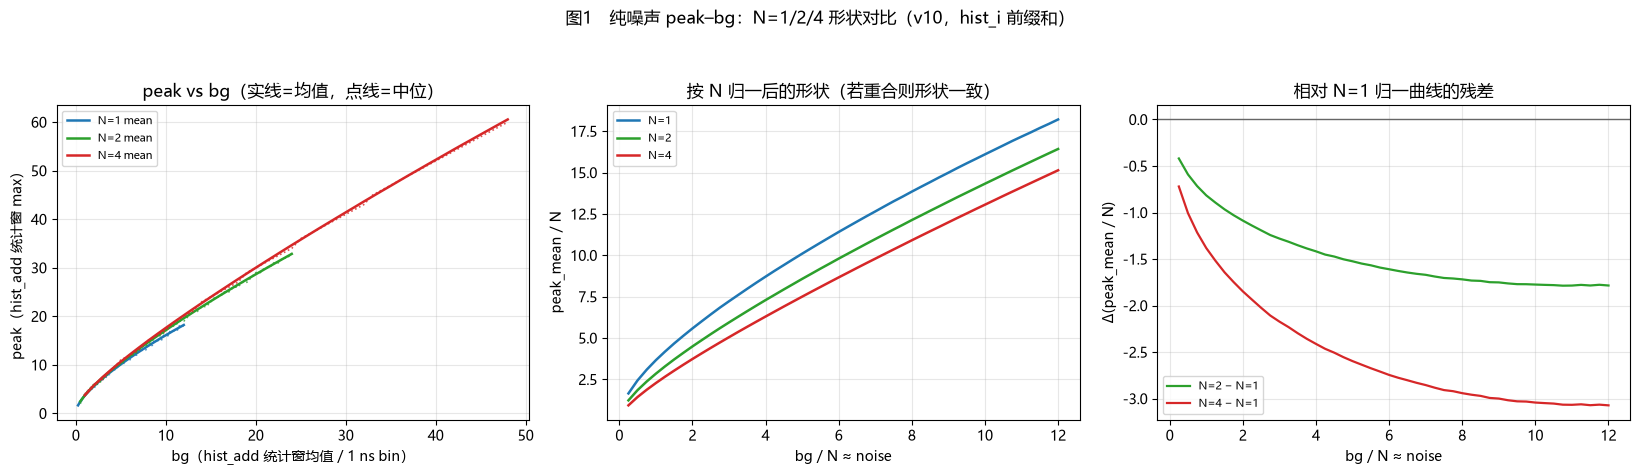

归一后 peak_mean/N 与 N=1 的 RMS 残差：
  N=2: RMS = 1.5171 计数
  N=4: RMS = 2.5924 计数


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))

for n in N_LIST:
    d = NOISE["by_N"][n]
    c = COLORS[n]
    ax[0].plot(d["bg_mc"], d["peak_mean"], "-", color=c, lw=1.8, label=f"N={n} mean")
    ax[0].plot(d["bg_mc"], d["peak_p50"], ":", color=c, lw=1.2, alpha=0.8)
ax[0].set_xlabel("bg（hist_add 统计窗均值 / 1 ns bin）")
ax[0].set_ylabel("peak（hist_add 统计窗 max）")
ax[0].set_title("peak vs bg（实线=均值，点线=中位）")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

# 形状对比：纵轴 / N，横轴 bg/N（≈noise）
for n in N_LIST:
    d = NOISE["by_N"][n]
    ax[1].plot(d["bg_mc"] / n, d["peak_mean"] / n, "-", color=COLORS[n], lw=1.8,
               label=f"N={n}")
ax[1].set_xlabel("bg / N ≈ noise")
ax[1].set_ylabel("peak_mean / N")
ax[1].set_title("按 N 归一后的形状（若重合则形状一致）")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

# 相对 N=1 的残差（在共同 bg/N 网格上插值）
d1 = NOISE["by_N"][1]
x1 = d1["bg_mc"] / 1.0
y1 = d1["peak_mean"] / 1.0
for n in [2, 4]:
    d = NOISE["by_N"][n]
    x = d["bg_mc"] / n
    y = d["peak_mean"] / n
    y_ref = np.interp(x, x1, y1)
    ax[2].plot(x, y - y_ref, "-", color=COLORS[n], lw=1.6, label=f"N={n} − N=1")
ax[2].axhline(0, color="0.4", lw=1)
ax[2].set_xlabel("bg / N ≈ noise")
ax[2].set_ylabel("Δ(peak_mean / N)")
ax[2].set_title("相对 N=1 归一曲线的残差")
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)

fig.suptitle("图1　纯噪声 peak–bg：N=1/2/4 形状对比（v10，hist_i 前缀和）", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("pod_v10_fig1_peak_vs_bg.png", dpi=120, bbox_inches="tight")
plt.show()

print("归一后 peak_mean/N 与 N=1 的 RMS 残差：")
for n in [2, 4]:
    d = NOISE["by_N"][n]
    x = d["bg_mc"] / n
    y = d["peak_mean"] / n
    y_ref = np.interp(x, x1, y1)
    rms = float(np.sqrt(np.mean((y - y_ref) ** 2)))
    print(f"  N={n}: RMS = {rms:.4f} 计数")

## 图 2　bg + 5·std(peak) 与 1% FAR 阈值

对每个 N、每个 bg：由 peak 的完整 `bincount` 得 std 与 1% 阈值 T（使 P(peak≥T) < 1% 的最小整数 T）。  
比较经验「均值≈bg 量级的底 + 5σ」规则与 MC 阈值。

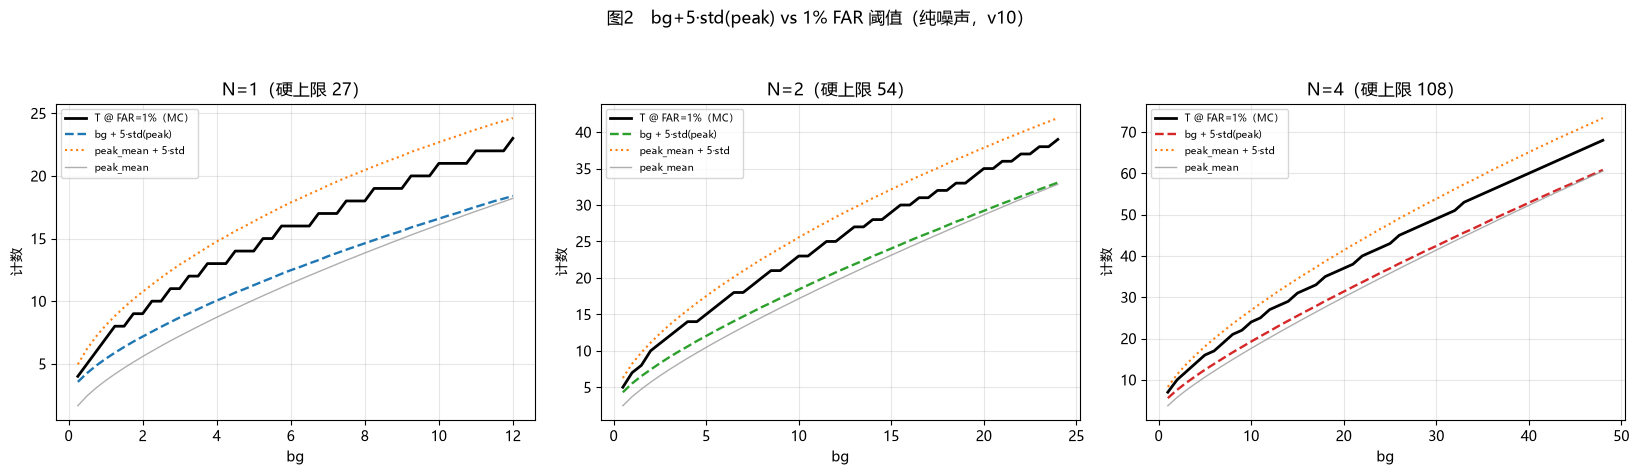

T_1pct − (bg+5σ) 的均值/最大绝对偏差：
  N=1: mean Δ=+3.13, max|Δ|=4.59, T 范围 4→23
  N=2: mean Δ=+4.29, max|Δ|=5.92, T 范围 5→39
  N=4: mean Δ=+5.78, max|Δ|=7.36, T 范围 7→68


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))

for j, n in enumerate(N_LIST):
    d = NOISE["by_N"][n]
    bg = d["bg_mc"]
    # 经验曲线：bg + 5*std(peak)；也画 peak_mean + 5*std 作对照
    y_bg5 = bg + 5.0 * d["peak_std"]
    y_mu5 = d["peak_mean"] + 5.0 * d["peak_std"]
    a = ax[j]
    a.plot(bg, d["T_1pct"], "-", color="k", lw=2.0, label="T @ FAR=1%（MC）")
    a.plot(bg, y_bg5, "--", color=COLORS[n], lw=1.7, label="bg + 5·std(peak)")
    a.plot(bg, y_mu5, ":", color="tab:orange", lw=1.5, label="peak_mean + 5·std")
    a.plot(bg, d["peak_mean"], "-", color="0.55", lw=1.0, alpha=0.7, label="peak_mean")
    a.set_xlabel("bg")
    a.set_ylabel("计数")
    a.set_title(f"N={n}（硬上限 {27*n}）")
    a.legend(fontsize=7.5); a.grid(alpha=0.3)

fig.suptitle("图2　bg+5·std(peak) vs 1% FAR 阈值（纯噪声，v10）", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("pod_v10_fig2_bg5std_vs_T1pct.png", dpi=120, bbox_inches="tight")
plt.show()

print("T_1pct − (bg+5σ) 的均值/最大绝对偏差：")
for n in N_LIST:
    d = NOISE["by_N"][n]
    diff = d["T_1pct"] - (d["bg_mc"] + 5.0 * d["peak_std"])
    print(f"  N={n}: mean Δ={diff.mean():+.2f}, max|Δ|={np.max(np.abs(diff)):.2f}, "
          f"T 范围 {d['T_1pct'][0]}→{d['T_1pct'][-1]}")

## 图 3　固定信号：noise 线性增长时 peak 分布是否只是平移？

对每个固定 boost，看 peak 分布随 noise 的变化：

- 若**只是平移**：`peak − peak_mean(noise)` 的分布应近似重叠；`std` 近似恒定  
- 若统计量**线性**：`peak_mean`、`std` 对 noise 近似直线

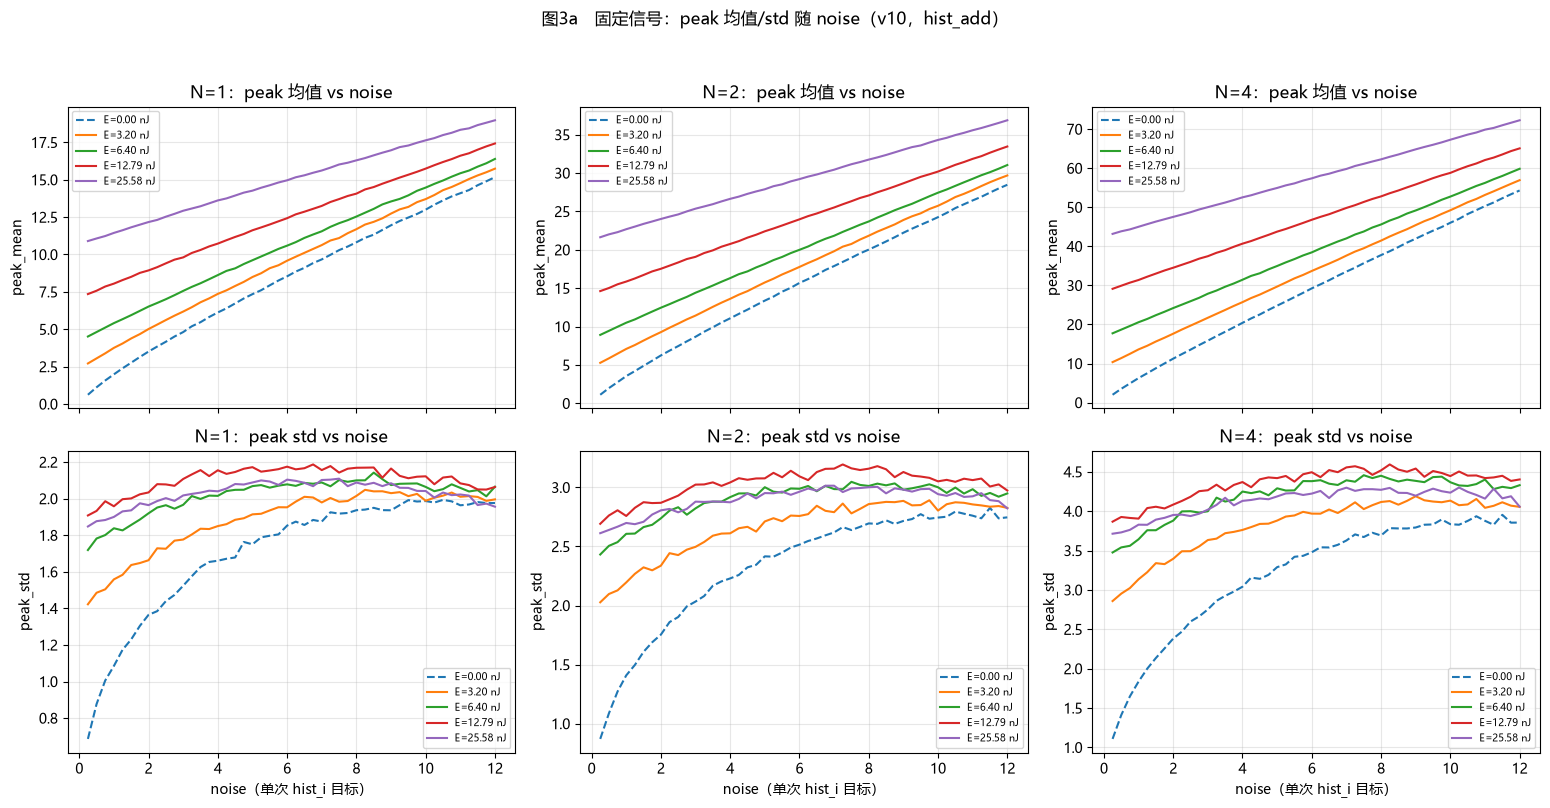

C:\Users\wangzuqing\AppData\Local\Temp\ipykernel_37304\3523280287.py:54: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Microsoft YaHei.
  fig.tight_layout(rect=[0, 0, 1, 0.93])
C:\Users\wangzuqing\AppData\Local\Temp\ipykernel_37304\3523280287.py:55: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Microsoft YaHei.
  fig.savefig("pod_v10_fig3b_shift_check.png", dpi=120, bbox_inches="tight")


C:\Users\wangzuqing\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


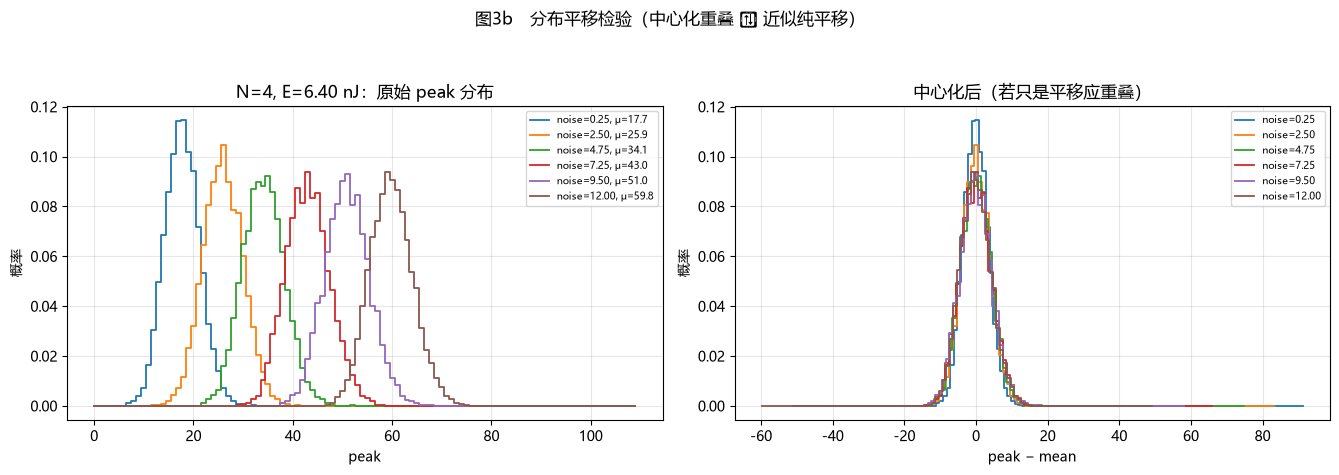

peak_mean 对 noise 的一次拟合斜率 / R²（各 N × boost）：
  N     E[nJ]     slope      R2     std斜率  std_R2
  1      0.00     1.202  0.9968     0.084  0.7912
  1      3.20     1.097  0.9985     0.043  0.7777
  1      6.40     0.999  0.9993     0.021  0.5631
  1     12.79     0.851  0.9997     0.008  0.1799
  1     25.58     0.684  0.9996     0.008  0.1874
  2      0.00     2.277  0.9982     0.130  0.8208
  2      3.20     2.067  0.9995     0.062  0.7954
  2      6.40     1.872  0.9998     0.033  0.5782
  2     12.79     1.592  0.9999     0.022  0.4215
  2     25.58     1.287  0.9999     0.021  0.4800
  4      0.00     4.382  0.9991     0.195  0.8378
  4      3.20     3.954  0.9999     0.090  0.7809
  4      6.40     3.573  1.0000     0.062  0.6571
  4     12.79     3.055  1.0000     0.044  0.6154
  4     25.58     2.471  1.0000     0.037  0.6001


In [4]:
if SIG is None:
    print("跳过图3：请先跑 python run_pod_v10_scan.py signal --workers 20")
else:
    boosts = SIG["boosts"]
    E_nJ = boosts * core.E_PULSE_BASE * 1e9
    noise_t = SIG["noise_target"]

    # --- 3a：均值 / std vs noise（每个 N 一张，多 boost）---
    fig, ax = plt.subplots(2, len(N_LIST), figsize=(5.2 * len(N_LIST), 8.2), sharex=True)
    if len(N_LIST) == 1:
        ax = np.asarray(ax).reshape(2, 1)
    for j, n in enumerate(N_LIST):
        d = SIG["by_N"][n]
        for i, (b, e) in enumerate(zip(boosts, E_nJ)):
            ls = "-" if b > 0 else "--"
            ax[0, j].plot(noise_t, d["peak_mean"][i], ls=ls, lw=1.5,
                          label=f"E={e:.2f} nJ")
            ax[1, j].plot(noise_t, d["peak_std"][i], ls=ls, lw=1.5,
                          label=f"E={e:.2f} nJ")
        ax[0, j].set_title(f"N={n}：peak 均值 vs noise")
        ax[1, j].set_title(f"N={n}：peak std vs noise")
        ax[0, j].set_ylabel("peak_mean"); ax[1, j].set_ylabel("peak_std")
        ax[1, j].set_xlabel("noise（单次 hist_i 目标）")
        ax[0, j].legend(fontsize=7); ax[1, j].legend(fontsize=7)
        ax[0, j].grid(alpha=0.3); ax[1, j].grid(alpha=0.3)
    fig.suptitle("图3a　固定信号：peak 均值/std 随 noise（v10，hist_add）", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig("pod_v10_fig3a_mean_std_vs_noise.png", dpi=120, bbox_inches="tight")
    plt.show()

    # --- 3b：分布平移检验（选 N=4、一个中等 boost、若干 noise 档）---
    n = 4
    i_boost = min(2, len(boosts) - 1)  # 默认第三档信号
    d = SIG["by_N"][n]
    ks = np.unique(np.linspace(0, len(noise_t) - 1, 6).astype(int))
    fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
    for k in ks:
        cnt = d["peak_cnt"][i_boost, k]
        s = peak_stats(cnt)
        x = np.arange(cnt.size)
        pmf = cnt / max(cnt.sum(), 1)
        ax[0].step(x, pmf, where="mid", lw=1.3,
                   label=f"noise={noise_t[k]:.2f}, μ={s['mean']:.1f}")
        # 中心化
        ax[1].step(x - s["mean"], pmf, where="mid", lw=1.3,
                   label=f"noise={noise_t[k]:.2f}")
    ax[0].set_xlabel("peak"); ax[0].set_ylabel("概率")
    ax[0].set_title(f"N={n}, E={E_nJ[i_boost]:.2f} nJ：原始 peak 分布")
    ax[0].legend(fontsize=7); ax[0].grid(alpha=0.3)
    ax[1].set_xlabel("peak − mean"); ax[1].set_ylabel("概率")
    ax[1].set_title("中心化后（若只是平移应重叠）")
    ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3)
    fig.suptitle("图3b　分布平移检验（中心化重叠 ⇒ 近似纯平移）", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig("pod_v10_fig3b_shift_check.png", dpi=120, bbox_inches="tight")
    plt.show()

    # --- 3c：线性拟合斜率表 ---
    print("peak_mean 对 noise 的一次拟合斜率 / R²（各 N × boost）：")
    print(f"{'N':>3}{'E[nJ]':>10}{'slope':>10}{'R2':>8}{'std斜率':>10}{'std_R2':>8}")
    for n in N_LIST:
        d = SIG["by_N"][n]
        x = noise_t
        for i, e in enumerate(E_nJ):
            y = d["peak_mean"][i]
            ys = d["peak_std"][i]
            coef = np.polyfit(x, y, 1)
            yhat = np.polyval(coef, x)
            ss_res = np.sum((y - yhat) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            coefs = np.polyfit(x, ys, 1)
            ysh = np.polyval(coefs, x)
            r2s = 1 - np.sum((ys - ysh) ** 2) / max(np.sum((ys - ys.mean()) ** 2), 1e-30)
            print(f"{n:>3}{e:>10.2f}{coef[0]:>10.3f}{r2:>8.4f}{coefs[0]:>10.3f}{r2s:>8.4f}")

## 口径复核与结论摘要

自动打印关键比值与判定句，便于写入手顺 / handoff。

In [5]:
print("=" * 72)
print("口径复核（纯噪声）")
for n in N_LIST:
    d = NOISE["by_N"][n]
    ratio = d["bg_mc"] / np.maximum(d["noise_mc"], 1e-12)
    print(f"  N={n}: 中位 bg/noise = {np.nanmedian(ratio):.3f} "
          f"（期望 ≈ {n}）")

print("\n图1 形状：见 RMS 残差（越小越一致）")
print("图2：若 bg+5σ 系统性低于/高于 T@1%，说明经验规则偏松/偏紧")
print("图3：R²(mean vs noise) 高且中心化分布重叠 ⇒ 近似平移+线性；"
      "否则存在饱和/死时间抢占等非线性")
print("=" * 72)

口径复核（纯噪声）
  N=1: 中位 bg/noise = 1.000 （期望 ≈ 1）
  N=2: 中位 bg/noise = 2.000 （期望 ≈ 2）
  N=4: 中位 bg/noise = 4.000 （期望 ≈ 4）

图1 形状：见 RMS 残差（越小越一致）
图2：若 bg+5σ 系统性低于/高于 T@1%，说明经验规则偏松/偏紧
图3：R²(mean vs noise) 高且中心化分布重叠 ⇒ 近似平移+线性；否则存在饱和/死时间抢占等非线性
